## <b><u>Infrared.city-1</u>: Tree detection</b>
### <b>Introduction</b>

As urban areas are expanding and global temperatures rise due to climate change, being able to understand how trees can help cool cities has become increasingly important. Furthermore, trees reduce the risk of flooding in cities and promote health and wellbeing. Our project aims at taking the first step in the direction of better tree coverage in urban areas by creating a model which is able to predict tree locations using satellite imagery of densely populated areas.
<br>

### <b>Notebook structure</b>

&nbsp;&nbsp;&nbsp;<b>1. Fetching & preparing the data</b><br>
&nbsp;&nbsp;&nbsp;<b>2. Exploratory data analysis</b><br>
&nbsp;&nbsp;&nbsp;<b>3. Training & testing the model</b><br>
&nbsp;&nbsp;&nbsp;<b>4. Exporting to database format</b><br>

### <b>Shared folder structure</b>
/home/jovyan/ideas-dslab-group1-shared/<br>
&ensp;&ensp;<b>raw_data/</b> (so I do not have to rescrape it)<br>
&ensp;&ensp;&ensp;&ensp;sentinel data/<br>
&ensp;&ensp;&ensp;&ensp;baumkataster data/<br>
&ensp;&ensp;&ensp;&ensp;osm data/<br>
&ensp;&ensp;<b>processed_data/</b><br>
&ensp;&ensp;&ensp;&ensp;tiles_images/<br>
&ensp;&ensp;&ensp;&ensp;tiles_masks/<br>
<br>

## <b>1. Fetching & preparing the data</b>

### Scraping the data

For our project we use following publicly available data:

1. <b><a href="https://www.data.gv.at/datasets/c91a4635-8b7d-43fe-9b27-d95dec8392a7?locale=en">Vienna Baumkataster</a></b> <i>Official City of Vienna tree cadastre with tree locations (GeoJSON)</i><br>

2. <b><a href="https://dataspace.copernicus.eu/data-collections/copernicus-sentinel-missions/sentinel-2">Sentinel-2 Satellite Images</a></b> <i>Multispectral satellite imagery including 10 m resolution bands (GeoTIFF)</i><br>

3. <b><a href="https://download.geofabrik.de/europe">OpenStreetMap Urban Features</a></b> <i>OpenStreetMap vector data, including urban context such as buildings and roads ((GeoJSON/shapefile)</i><br>

We have approx. 154gb free space:<br>

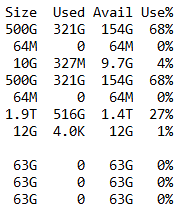<br>

And 117gb ram:<br>
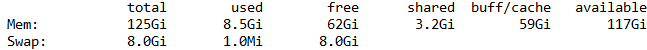:<br>

<b>With that, we can now fetch our datasets accordingly:

In [1]:
#1.getting buamkataster
#Lizenz: https://creativecommons.org/licenses/by/4.0/deed.de
#BEZIRK: Wiener Gemeindebezirk, in dem der Baum steht; OBJEKT_STRASSE: Anlage, Objekt oder Straße, in der der Baum steht; BAUMNUMMER: Nummer des Baumes; GEBIETSGRUPPE: Gebiet, in dem der Baum steht; GATTUNG_ART: Information, um welche Baumart es sich handelt; PFLANZJAHR: das Jahr, in dem der Baum gepflanzt wurde; PFLANZJAHR_TXT: Werte aus PFLANZJAHR in Textformat, Nullwerte werden in Text "nicht bekannt" umgewandelt; STAMMUMFANG: Umfang des Baumstammes in cm in einem Meter Höhe; STAMMUMFANG_TXT: Werte aus STAMMUMFANG in Textformat mit Zusatz " cm", Nullwerte werden in Text "nicht bekannt" umgewandelt; BAUMHOEHE: Einteilung in 8 Größenkategorien der Baumhöhe + Nullwert; BAUMHOEHE_TXT: Größenkategorien der Baumhöhe in Textformat direkt aus Quelldatenbank, Leereinträge werden in Text "nicht bekannt" umgewandelt; KRONENDURCHMESSER: Einteilung in 8 Größenkategorien des Baumkronendurchmessers + Nullwert; KRONENDURCHMESSER_TXT: Größenkategorien der Kronendurchmesser in Textformat direkt aus Quelldatenbank, Leereinträge werden in Text "nicht bekannt" umgewandelt;
#path to shared folder: /home/jovyan/ideas-dslab-group1-shared
import requests

r = requests.get("https://data.wien.gv.at/daten/geo?service=WFS&version=1.1.0&request=GetFeature&typeName=ogdwien:BAUMKATOGD&outputFormat=json&srsName=EPSG:4326")
open("/home/jovyan/ideas-dslab-group1-shared/baumkataster data/vienna_baumkataster.geojson", "wb").write(r.content)

137309796

In [3]:
!pip install geopandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.5/32.5 MB 85.8 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 30.3 MB/s  0:00:00eta 0:00:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 47.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [geopandas]/4 [geopandas]


In [4]:
import geopandas as gpd

baumkataster = gpd.read_file("/home/jovyan/ideas-dslab-group1-shared/baumkataster data/vienna_baumkataster.geojson")
print(baumkataster.head())
print(len(baumkataster))

                     id   OBJECTID  BAUM_ID DATENFUEHRUNG  BEZIRK  \
0  BAUMKATOGD.780540084  780540084   344016     magistrat     2.0   
1  BAUMKATOGD.780540085  780540085   282486     magistrat     2.0   
2  BAUMKATOGD.780540086  780540086   157598     magistrat    22.0   
3  BAUMKATOGD.780540087  780540087   282483     magistrat     2.0   
4  BAUMKATOGD.780540088  780540088   282481     magistrat     2.0   

                 OBJEKT_STRASSE          GEBIETSGRUPPE  \
0  02., Prater - Pelzmais, MA42     MA 42 - Parkanlage   
1  02., Prater - Pelzmais, MA42     MA 42 - Parkanlage   
2               Wagramer Straße  Hauptstraße B8/B3b/S2   
3  02., Prater - Pelzmais, MA42     MA 42 - Parkanlage   
4  02., Prater - Pelzmais, MA42     MA 42 - Parkanlage   

                             GATTUNG_ART  PFLANZJAHR PFLANZJAHR_TXT  \
0        Juglans nigra (Schwarznussbaum)        2020           2020   
1    Robinia pseudoacacia (Scheinakazie)        1918           1918   
2          Acer platano

In [ ]:
#2.getting sential-2 satellite images


In [ ]:
#3.getting openStreetMap urban features



### Cleaning the data

<b>We will now prepare our datasets:</b>